<a href="https://colab.research.google.com/github/abdulhaseeb941/flyrank-search-intelligence-capstone/blob/main/FlyRank_Capstone_Refresh_Opportunity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install duckdb huggingface_hub pandas pyarrow scikit-learn matplotlib seaborn

In [6]:
from google.colab import userdata
import duckdb

# Get the token securely from Colab Secrets
HF_TOKEN = userdata.get("HF_TOKEN")

# Create DuckDB connection
con = duckdb.connect()

# Pass the token securely to DuckDB
con.execute("SET VARIABLE hf_token = ?", [HF_TOKEN])

con.execute("""
    CREATE SECRET hf_secret (
        TYPE huggingface,
        TOKEN getvariable('hf_token')
    )
""")

print("Hugging Face connection created successfully!")

Hugging Face connection created successfully!


In [7]:
# FlyRank warehouse location
warehouse = "hf://datasets/FlyRank/internship-warehouse"

print("Warehouse path set:")
print(warehouse)

Warehouse path set:
hf://datasets/FlyRank/internship-warehouse


In [8]:
query = f"""
SELECT COUNT(*) AS row_count
FROM read_parquet(
    '{warehouse}/fact_content_daily_performance/**/*.parquet'
)
"""

result = con.sql(query)
result

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────┐
│ row_count │
│   int64   │
├───────────┤
│  78835655 │
└───────────┘

In [9]:
query = f"""
DESCRIBE
SELECT *
FROM read_parquet(
    '{warehouse}/fact_content_daily_performance/**/*.parquet'
)
"""

columns = con.sql(query)
columns

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

In [10]:
query = f"""
SELECT *
FROM read_parquet(
    '{warehouse}/fact_content_daily_performance/**/*.parquet'
)
LIMIT 10
"""

sample = con.sql(query)
sample

┌─────────────┬─────────────────────────┬──────────────────────────┬────────────────┬────────────────┬────────────────────┬────────────────────┬─────────────────┬────────────┬──────────────────┬────────────────────┬───────────────┬──────────────┬───────────┬──────────────────────┬──────────────────────────┬──────────────────┬─────────────────┬───────────────────┬─────────────────┬───────────────┬─────────────┬────────────┬───────────────┬───────────┬────────────┬───────────┬─────────┬──────────┬───────────────┬─────────┐
│ report_date │     client_hash_id      │     content_hash_id      │ client_has_gsc │ client_has_ga4 │ gsc_data_available │ ga4_data_available │ gsc_impressions │ gsc_clicks │ gsc_sum_position │  gsc_avg_position  │ ga4_pageviews │ ga4_sessions │ ga4_users │ ga4_engaged_sessions │ ga4_total_engagement_sec │ sessions_organic │ sessions_direct │ sessions_referral │ sessions_social │ sessions_paid │ sessions_ai │ ai_chatgpt │ ai_perplexity │ ai_gemini │ ai_copilot │ ai_cl

In [11]:
# Show the exact columns in the FlyRank performance table

schema = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{warehouse}/fact_content_daily_performance/**/*.parquet'
    )
""").df()

schema[["column_name", "column_type"]]

,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


In [12]:
# Check the date range in the dataset

dates = con.sql(f"""
    SELECT
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS number_of_days
    FROM read_parquet(
        '{warehouse}/fact_content_daily_performance/**/*.parquet'
    )
""")

dates

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬────────────┬────────────────┐
│ first_date │ last_date  │ number_of_days │
│    date    │    date    │     int64      │
├────────────┼────────────┼────────────────┤
│ 2025-01-27 │ 2026-06-30 │            520 │
└────────────┴────────────┴────────────────┘

In [13]:
# STEP 9.1
# Check how many content items have enough baseline impressions
# and how often a 20%+ decline occurs in the following 28 days.

query = f"""
WITH daily AS (
    SELECT
        report_date,
        content_hash_id,
        SUM(gsc_impressions) AS impressions
    FROM read_parquet(
        '{warehouse}/fact_content_daily_performance/**/*.parquet'
    )
    GROUP BY report_date, content_hash_id
),

windows AS (
    SELECT
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-04-01' AND DATE '2026-04-28'
                THEN impressions
                ELSE 0
            END
        ) AS baseline_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN DATE '2026-04-29' AND DATE '2026-05-26'
                THEN impressions
                ELSE 0
            END
        ) AS future_impressions

    FROM daily
    GROUP BY content_hash_id
)

SELECT
    COUNT(*) AS total_content,
    COUNT(*) FILTER (
        WHERE baseline_impressions >= 100
    ) AS eligible_content,

    COUNT(*) FILTER (
        WHERE baseline_impressions >= 100
        AND future_impressions <= baseline_impressions * 0.80
    ) AS declining_content

FROM windows;
"""

label_check = con.sql(query)
label_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────┬──────────────────┬───────────────────┐
│ total_content │ eligible_content │ declining_content │
│     int64     │      int64       │       int64       │
├───────────────┼──────────────────┼───────────────────┤
│        427292 │           104622 │             58986 │
└───────────────┴──────────────────┴───────────────────┘

In [15]:
# STEP 10.1 — Corrected modeling dataset

query = f"""
WITH daily AS (
    SELECT
        report_date,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_sum_position) AS sum_position,
        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions
    FROM read_parquet(
        '{warehouse}/fact_content_daily_performance/**/*.parquet'
    )
    GROUP BY report_date, content_hash_id
),

snapshots AS (
    SELECT *
    FROM (
        VALUES
            (DATE '2025-04-25'),
            (DATE '2025-05-23'),
            (DATE '2025-06-20'),
            (DATE '2025-07-18'),
            (DATE '2025-08-15'),
            (DATE '2025-09-12'),
            (DATE '2025-10-10'),
            (DATE '2025-11-07'),
            (DATE '2025-12-05'),
            (DATE '2026-01-02'),
            (DATE '2026-01-30'),
            (DATE '2026-02-27'),
            (DATE '2026-03-27'),
            (DATE '2026-04-24'),
            (DATE '2026-05-22')
    ) AS t(snapshot_date)
),

features AS (
    SELECT
        s.snapshot_date,
        d.content_hash_id,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date
                THEN d.impressions ELSE 0
            END
        ) AS baseline_impressions,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date
                THEN d.clicks ELSE 0
            END
        ) AS baseline_clicks,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date
                THEN d.sum_position ELSE 0
            END
        ) AS baseline_sum_position,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date
                THEN d.pageviews ELSE 0
            END
        ) AS baseline_pageviews,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date
                THEN d.sessions ELSE 0
            END
        ) AS baseline_sessions,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date - INTERVAL 14 DAY
                THEN d.impressions ELSE 0
            END
        ) AS early_impressions,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 13 DAY
                     AND s.snapshot_date
                THEN d.impressions ELSE 0
            END
        ) AS recent_impressions,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 27 DAY
                     AND s.snapshot_date - INTERVAL 14 DAY
                THEN d.clicks ELSE 0
            END
        ) AS early_clicks,

        SUM(
            CASE
                WHEN d.report_date BETWEEN
                     s.snapshot_date - INTERVAL 13 DAY
                     AND s.snapshot_date
                THEN d.clicks ELSE 0
            END
        ) AS recent_clicks

    FROM snapshots s
    JOIN daily d
        ON d.report_date BETWEEN
           s.snapshot_date - INTERVAL 27 DAY
           AND s.snapshot_date

    GROUP BY
        s.snapshot_date,
        d.content_hash_id
),

future AS (
    SELECT
        s.snapshot_date,
        d.content_hash_id,
        SUM(d.impressions) AS future_impressions

    FROM snapshots s
    JOIN daily d
        ON d.report_date >
           s.snapshot_date
        AND d.report_date <=
           s.snapshot_date + INTERVAL 28 DAY

    GROUP BY
        s.snapshot_date,
        d.content_hash_id
)

SELECT
    f.snapshot_date,
    f.content_hash_id,

    f.baseline_impressions,
    f.baseline_clicks,

    CASE
        WHEN f.baseline_impressions > 0
        THEN f.baseline_clicks * 1.0 / f.baseline_impressions
        ELSE 0
    END AS baseline_ctr,

    CASE
        WHEN f.baseline_impressions > 0
        THEN f.baseline_sum_position * 1.0 / f.baseline_impressions
        ELSE NULL
    END AS baseline_avg_position,

    f.baseline_pageviews,
    f.baseline_sessions,

    CASE
        WHEN f.early_impressions > 0
        THEN f.recent_impressions * 1.0 / f.early_impressions - 1
        ELSE 0
    END AS impression_momentum,

    CASE
        WHEN f.early_clicks > 0
        THEN f.recent_clicks * 1.0 / f.early_clicks - 1
        ELSE 0
    END AS click_momentum,

    fu.future_impressions,

    CASE
        WHEN fu.future_impressions <= f.baseline_impressions * 0.80
        THEN 1
        ELSE 0
    END AS decline_label

FROM features f

INNER JOIN future fu
    ON f.snapshot_date = fu.snapshot_date
    AND f.content_hash_id = fu.content_hash_id

WHERE f.baseline_impressions >= 100
"""

model_data = con.sql(query).df()

print("Modeling dataset created!")
print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))

model_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling dataset created!
Rows: 674457
Columns: 12


,snapshot_date,content_hash_id,baseline_impressions,baseline_clicks,baseline_ctr,baseline_avg_position,baseline_pageviews,baseline_sessions,impression_momentum,click_momentum,future_impressions,decline_label
0,2025-06-20,content_1b8d21b3b98cb239,2888.0,15.0,0.005194,4.786357,0.0,0.0,0.000000,0.0,8170.0,0
1,2025-06-20,content_313a6b5384b51262,1132.0,3.0,0.002650,15.895760,0.0,0.0,0.602299,1.0,1911.0,0
2,2025-06-20,content_a0107356b1981a6f,464.0,0.0,0.000000,8.877155,0.0,0.0,-0.158730,0.0,287.0,1
3,2025-06-20,content_7f96b78c9e7dc29c,706.0,2.0,0.002833,11.743626,0.0,0.0,-0.358140,0.0,1418.0,0
4,2025-06-20,content_6d1ecd76d6607d00,236.0,0.0,0.000000,9.635593,0.0,0.0,0.360000,0.0,289.0,0


In [16]:
# STEP 11 — Data quality checks

print("=== DATA QUALITY CHECK ===")

# 1. Missing values
print("\nMissing values:")
print(model_data.isna().sum())

# 2. Duplicate rows
print("\nDuplicate rows:")
print(model_data.duplicated().sum())

# 3. Label balance
print("\nDecline label balance:")
print(model_data["decline_label"].value_counts())
print("\nDecline label percentage:")
print(
    (model_data["decline_label"].value_counts(normalize=True) * 100)
    .round(2)
)

# 4. Basic feature ranges
print("\nFeature ranges:")
print(
    model_data[
        [
            "baseline_impressions",
            "baseline_clicks",
            "baseline_ctr",
            "baseline_avg_position",
            "baseline_pageviews",
            "baseline_sessions",
            "impression_momentum",
            "click_momentum"
        ]
    ].describe().T
)

=== DATA QUALITY CHECK ===

Missing values:
snapshot_date                 0
content_hash_id               0
baseline_impressions          0
baseline_clicks               0
baseline_ctr                  0
baseline_avg_position         0
baseline_pageviews       184538
baseline_sessions        184538
impression_momentum           0
click_momentum                0
future_impressions            0
decline_label                 0
dtype: int64

Duplicate rows:
0

Decline label balance:
decline_label
0    421690
1    252767
Name: count, dtype: int64

Decline label percentage:
decline_label
0    62.52
1    37.48
Name: proportion, dtype: float64

Feature ranges:
                          count         mean          std    min         25%  \
baseline_impressions   674457.0  2144.773559  5693.967553  100.0  245.000000   
baseline_clicks        674457.0     7.201985    30.799933    0.0    0.000000   
baseline_ctr           674457.0     0.003042     0.004946    0.0    0.000000   
baseline_avg_positi

In [17]:
# STEP 12 — Time-aware train/test split

# Training period: earlier snapshots
train_data = model_data[
    model_data["snapshot_date"] <= "2026-02-27"
].copy()

# Test period: later snapshots
test_data = model_data[
    model_data["snapshot_date"] >= "2026-03-27"
].copy()

print("=== TIME-AWARE SPLIT ===")

print("\nTraining rows:", len(train_data))
print("Test rows:", len(test_data))

print("\nTraining snapshot dates:")
print(sorted(train_data["snapshot_date"].unique()))

print("\nTest snapshot dates:")
print(sorted(test_data["snapshot_date"].unique()))

print("\nTraining label balance:")
print(train_data["decline_label"].value_counts(normalize=True).round(3))

print("\nTest label balance:")
print(test_data["decline_label"].value_counts(normalize=True).round(3))

=== TIME-AWARE SPLIT ===

Training rows: 365673
Test rows: 308784

Training snapshot dates:
[Timestamp('2025-04-25 00:00:00'), Timestamp('2025-05-23 00:00:00'), Timestamp('2025-06-20 00:00:00'), Timestamp('2025-07-18 00:00:00'), Timestamp('2025-08-15 00:00:00'), Timestamp('2025-09-12 00:00:00'), Timestamp('2025-10-10 00:00:00'), Timestamp('2025-11-07 00:00:00'), Timestamp('2025-12-05 00:00:00'), Timestamp('2026-01-02 00:00:00'), Timestamp('2026-01-30 00:00:00'), Timestamp('2026-02-27 00:00:00')]

Test snapshot dates:
[Timestamp('2026-03-27 00:00:00'), Timestamp('2026-04-24 00:00:00'), Timestamp('2026-05-22 00:00:00')]

Training label balance:
decline_label
0    0.76
1    0.24
Name: proportion, dtype: float64

Test label balance:
decline_label
1    0.534
0    0.466
Name: proportion, dtype: float64


In [18]:
# STEP 13 — Simple baseline

# Baseline rule:
# Predict decline when recent impressions are lower than earlier impressions.

test_data = test_data.copy()

test_data["baseline_prediction"] = (
    test_data["impression_momentum"] < 0
).astype(int)

print("=== BASELINE RESULTS ===")

print("\nBaseline predictions:")
print(test_data["baseline_prediction"].value_counts())

print("\nActual labels:")
print(test_data["decline_label"].value_counts())

=== BASELINE RESULTS ===

Baseline predictions:
baseline_prediction
0    157261
1    151523
Name: count, dtype: int64

Actual labels:
decline_label
1    164916
0    143868
Name: count, dtype: int64


In [19]:
# STEP 14 — Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# Features available before the future 28-day period
features = [
    "baseline_impressions",
    "baseline_clicks",
    "baseline_ctr",
    "baseline_avg_position",
    "baseline_pageviews",
    "baseline_sessions",
    "impression_momentum",
    "click_momentum"
]

X_train = train_data[features]
y_train = train_data["decline_label"]

X_test = test_data[features]
y_test = test_data["decline_label"]

# Fill any missing feature values using training-set medians
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train_imputed, y_train)

# Predictions
test_data["ml_prediction"] = model.predict(X_test_imputed)

# Probability of future decline
test_data["ml_probability"] = model.predict_proba(
    X_test_imputed
)[:, 1]

print("=== MODEL TRAINED ===")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features:", len(features))
print("Model: Random Forest")

=== MODEL TRAINED ===
Training rows: 365673
Test rows: 308784
Features: 8
Model: Random Forest


In [20]:
# STEP 15 — Evaluate baseline vs ML model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Baseline metrics
baseline_accuracy = accuracy_score(
    y_test,
    test_data["baseline_prediction"]
)

baseline_precision = precision_score(
    y_test,
    test_data["baseline_prediction"],
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    test_data["baseline_prediction"],
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    test_data["baseline_prediction"],
    zero_division=0
)

# ML model metrics
ml_accuracy = accuracy_score(
    y_test,
    test_data["ml_prediction"]
)

ml_precision = precision_score(
    y_test,
    test_data["ml_prediction"],
    zero_division=0
)

ml_recall = recall_score(
    y_test,
    test_data["ml_prediction"],
    zero_division=0
)

ml_f1 = f1_score(
    y_test,
    test_data["ml_prediction"],
    zero_division=0
)

ml_auc = roc_auc_score(
    y_test,
    test_data["ml_probability"]
)

print("=== MODEL COMPARISON ===")

print("\nBASELINE")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

print("\nRANDOM FOREST")
print("Accuracy :", round(ml_accuracy, 4))
print("Precision:", round(ml_precision, 4))
print("Recall   :", round(ml_recall, 4))
print("F1 Score :", round(ml_f1, 4))
print("ROC-AUC  :", round(ml_auc, 4))

=== MODEL COMPARISON ===

BASELINE
Accuracy : 0.6457
Precision: 0.6832
Recall   : 0.6277
F1 Score : 0.6543

RANDOM FOREST
Accuracy : 0.6217
Precision: 0.6543
Recall   : 0.6185
F1 Score : 0.6359
ROC-AUC  : 0.6685


=== FEATURE IMPORTANCE ===
                 feature  importance
6    impression_momentum    0.551811
3  baseline_avg_position    0.156808
2           baseline_ctr    0.095223
0   baseline_impressions    0.054135
1        baseline_clicks    0.050420
7         click_momentum    0.036882
4     baseline_pageviews    0.027364
5      baseline_sessions    0.027359


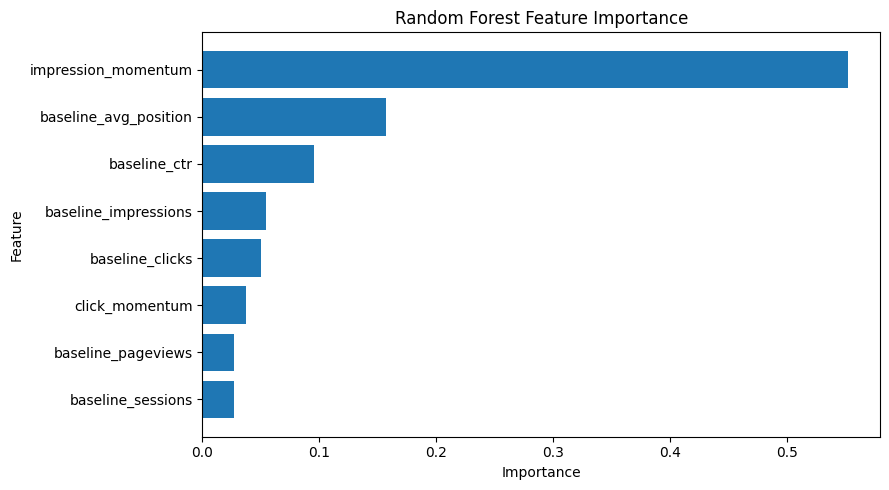

In [21]:
# STEP 16 — Feature importance

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("=== FEATURE IMPORTANCE ===")
print(importance)

# Plot
plt.figure(figsize=(9, 5))

plt.barh(
    importance["feature"][::-1],
    importance["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [22]:
# STEP 17 — Ranked content recommendations

recommendations = test_data.copy()

# Rank pages by predicted probability of future decline
recommendations = recommendations.sort_values(
    "ml_probability",
    ascending=False
).reset_index(drop=True)

# Generate reason codes
def get_reason(row):
    reasons = []

    if row["impression_momentum"] < -0.20:
        reasons.append("impressions falling")

    if row["click_momentum"] < -0.20:
        reasons.append("clicks falling")

    if row["baseline_avg_position"] > 10:
        reasons.append("weaker average position")

    if row["baseline_ctr"] < 0.02:
        reasons.append("low CTR")

    if not reasons:
        reasons.append("multiple weaker performance signals")

    return "; ".join(reasons[:2])

recommendations["reason"] = recommendations.apply(
    get_reason,
    axis=1
)

# Final recommendation columns
ranked_recommendations = recommendations[
    [
        "snapshot_date",
        "content_hash_id",
        "ml_probability",
        "baseline_impressions",
        "baseline_clicks",
        "baseline_ctr",
        "baseline_avg_position",
        "impression_momentum",
        "click_momentum",
        "reason"
    ]
].copy()

ranked_recommendations["rank"] = (
    ranked_recommendations.index + 1
)

ranked_recommendations = ranked_recommendations[
    [
        "rank",
        "snapshot_date",
        "content_hash_id",
        "ml_probability",
        "baseline_impressions",
        "baseline_clicks",
        "baseline_ctr",
        "baseline_avg_position",
        "impression_momentum",
        "click_momentum",
        "reason"
    ]
]

print("=== TOP 20 REFRESH OPPORTUNITIES ===")

display(
    ranked_recommendations.head(20)
)

=== TOP 20 REFRESH OPPORTUNITIES ===


,rank,snapshot_date,content_hash_id,ml_probability,baseline_impressions,baseline_clicks,baseline_ctr,baseline_avg_position,impression_momentum,click_momentum,reason
0,1,2026-05-22,content_7d87c69eaba32c8c,0.967891,5897.0,248.0,0.042055,6.045616,-0.868573,-0.966667,impressions falling; clicks falling
1,2,2026-04-24,content_fa4b9e9229816684,0.962060,10959.0,378.0,0.034492,7.822703,-0.965839,-0.989305,impressions falling; clicks falling
2,3,2026-03-27,content_c5e2e71596d4023c,0.961652,4517.0,168.0,0.037193,5.727917,-0.840308,-0.909091,impressions falling; clicks falling
3,4,2026-04-24,content_a6d10222adf4e57c,0.961263,10567.0,228.0,0.021577,8.894861,-0.948034,-0.991150,impressions falling; clicks falling
4,5,2026-05-22,content_4dde1e0f5c4cc65f,0.961240,12806.0,337.0,0.026316,8.845619,-0.932299,-0.981873,impressions falling; clicks falling
5,6,2026-04-24,content_9407576c428276ba,0.957583,23589.0,209.0,0.008860,6.029802,-0.976261,-1.000000,impressions falling; clicks falling
6,7,2026-05-22,content_597d0e48fabdd58e,0.956022,11493.0,116.0,0.010093,10.062038,-0.886337,-0.954955,impressions falling; clicks falling
7,8,2026-05-22,content_28bc64306079081a,0.955813,17053.0,192.0,0.011259,7.240896,-0.955342,-0.967742,impressions falling; clicks falling
8,9,2026-04-24,content_eb98cb59a8b11f7a,0.954562,20871.0,173.0,0.008289,7.648268,-0.960400,-0.982353,impressions falling; clicks falling
9,10,2026-04-24,content_5641994617569b14,0.954192,19567.0,198.0,0.010119,6.673021,-0.967114,-0.989796,impressions falling; clicks falling


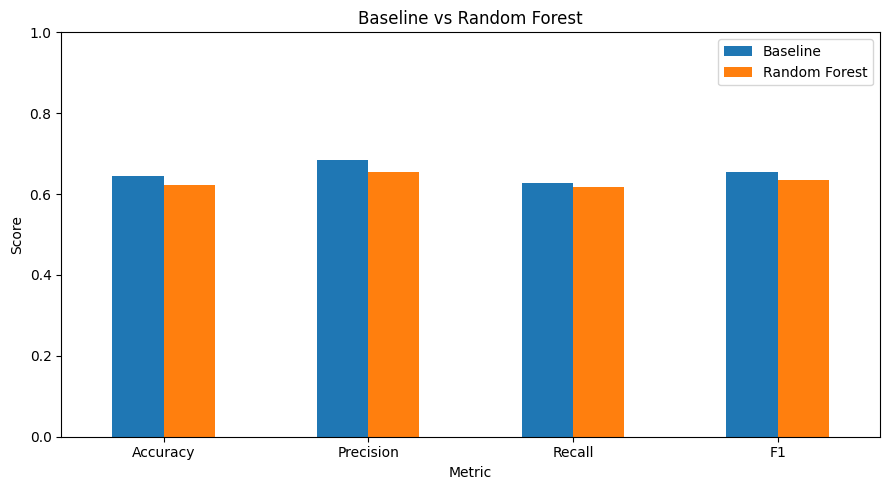

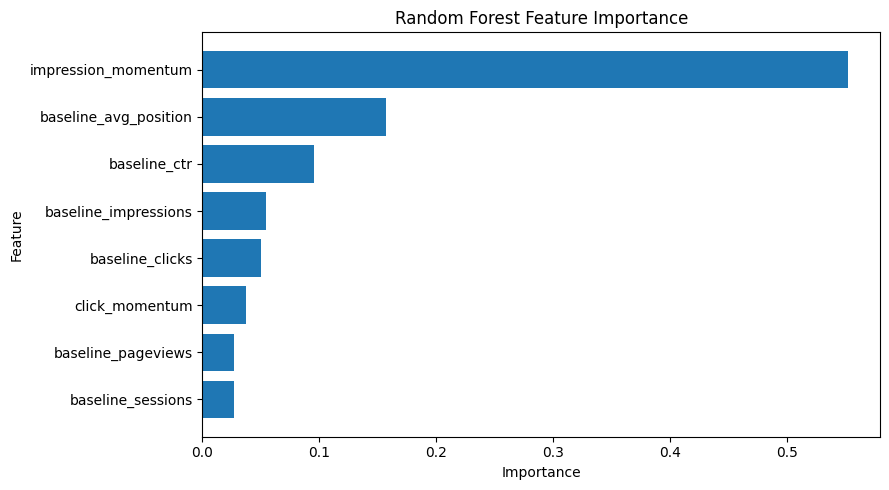

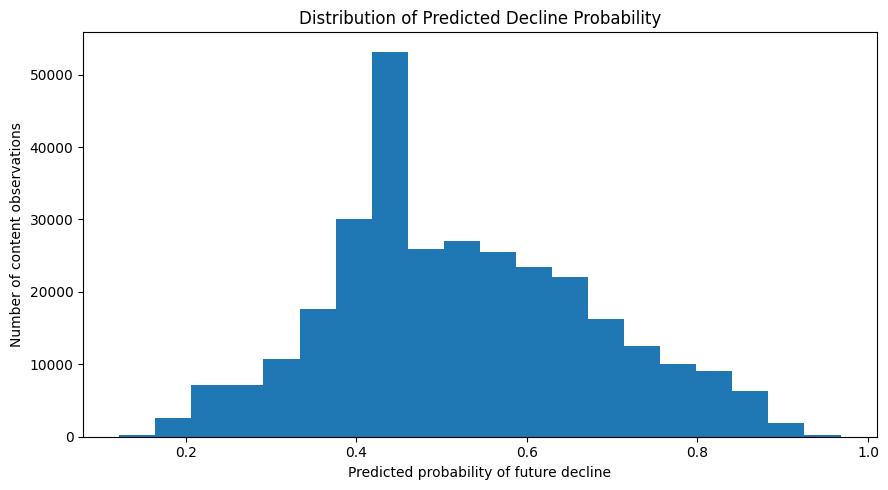

In [23]:
# STEP 18 — Results charts

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Chart 1 — Model comparison
# -----------------------------

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Random Forest": [
        ml_accuracy,
        ml_precision,
        ml_recall,
        ml_f1
    ]
})

metrics_plot = metrics.set_index("Metric")

metrics_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# -----------------------------
# Chart 2 — Feature importance
# -----------------------------

plt.figure(figsize=(9, 5))

plt.barh(
    importance["feature"][::-1],
    importance["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


# -----------------------------
# Chart 3 — Predicted probability
# -----------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    recommendations["ml_probability"],
    bins=20
)

plt.xlabel("Predicted probability of future decline")
plt.ylabel("Number of content observations")
plt.title("Distribution of Predicted Decline Probability")

plt.tight_layout()
plt.show()

In [24]:
# STEP 19 — Save analysis outputs

# Save ranked recommendations
ranked_recommendations.to_csv(
    "ranked_refresh_recommendations.csv",
    index=False
)

# Save model comparison metrics
metrics.to_csv(
    "model_comparison_metrics.csv",
    index=False
)

# Save feature importance
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("=== OUTPUT FILES SAVED ===")
print("1. ranked_refresh_recommendations.csv")
print("2. model_comparison_metrics.csv")
print("3. feature_importance.csv")

=== OUTPUT FILES SAVED ===
1. ranked_refresh_recommendations.csv
2. model_comparison_metrics.csv
3. feature_importance.csv


In [25]:
# STEP 20 — Capstone summary

print("=" * 60)
print("FLYRANK CAPSTONE — REFRESH OPPORTUNITY SCORING")
print("=" * 60)

print("\nDATASET")
print("Modeling rows:", len(model_data))
print("Training rows:", len(train_data))
print("Test rows:", len(test_data))

print("\nLABEL")
print(
    "Training decline rate:",
    round(train_data["decline_label"].mean() * 100, 2),
    "%"
)
print(
    "Test decline rate:",
    round(test_data["decline_label"].mean() * 100, 2),
    "%"
)

print("\nMODEL PERFORMANCE")

print("\nBaseline:")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

print("\nRandom Forest:")
print("Accuracy :", round(ml_accuracy, 4))
print("Precision:", round(ml_precision, 4))
print("Recall   :", round(ml_recall, 4))
print("F1 Score :", round(ml_f1, 4))
print("ROC-AUC  :", round(ml_auc, 4))

print("\nTOP FEATURES")

for _, row in importance.head(8).iterrows():
    print(
        f"{row['feature']}: "
        f"{row['importance']:.4f}"
    )

print("\nTOP 10 RECOMMENDATIONS")

display(
    ranked_recommendations[
        [
            "rank",
            "content_hash_id",
            "ml_probability",
            "reason"
        ]
    ].head(10)
)

print("\n" + "=" * 60)
print("SUMMARY COMPLETE")
print("=" * 60)

FLYRANK CAPSTONE — REFRESH OPPORTUNITY SCORING

DATASET
Modeling rows: 674457
Training rows: 365673
Test rows: 308784

LABEL
Training decline rate: 24.02 %
Test decline rate: 53.41 %

MODEL PERFORMANCE

Baseline:
Accuracy : 0.6457
Precision: 0.6832
Recall   : 0.6277
F1 Score : 0.6543

Random Forest:
Accuracy : 0.6217
Precision: 0.6543
Recall   : 0.6185
F1 Score : 0.6359
ROC-AUC  : 0.6685

TOP FEATURES
impression_momentum: 0.5518
baseline_avg_position: 0.1568
baseline_ctr: 0.0952
baseline_impressions: 0.0541
baseline_clicks: 0.0504
click_momentum: 0.0369
baseline_pageviews: 0.0274
baseline_sessions: 0.0274

TOP 10 RECOMMENDATIONS


,rank,content_hash_id,ml_probability,reason
0,1,content_7d87c69eaba32c8c,0.967891,impressions falling; clicks falling
1,2,content_fa4b9e9229816684,0.962060,impressions falling; clicks falling
2,3,content_c5e2e71596d4023c,0.961652,impressions falling; clicks falling
3,4,content_a6d10222adf4e57c,0.961263,impressions falling; clicks falling
4,5,content_4dde1e0f5c4cc65f,0.961240,impressions falling; clicks falling
5,6,content_9407576c428276ba,0.957583,impressions falling; clicks falling
6,7,content_597d0e48fabdd58e,0.956022,impressions falling; clicks falling
7,8,content_28bc64306079081a,0.955813,impressions falling; clicks falling
8,9,content_eb98cb59a8b11f7a,0.954562,impressions falling; clicks falling
9,10,content_5641994617569b14,0.954192,impressions falling; clicks falling



SUMMARY COMPLETE


In [26]:
# STEP 21 — Research paper draft

paper = f"""
# Predicting Organic Search Visibility Decline from Recent Performance Signals

## Abstract

This study investigates whether recent search-performance signals can identify content that is likely to experience a meaningful decline in organic search visibility over the following 28 days. Using the FlyRank search-performance warehouse, I constructed a time-aware dataset of {len(model_data):,} content observations across multiple historical snapshots. The target label marks observations where future 28-day impressions declined by at least 20 percent relative to the preceding 28-day baseline, subject to a minimum baseline of 100 impressions. A simple impression-momentum baseline was compared with a Random Forest classifier using search and engagement signals available before the prediction period. On the held-out future test period, the baseline achieved an F1 score of {baseline_f1:.4f}, while the Random Forest achieved an F1 score of {ml_f1:.4f} and a ROC-AUC of {ml_auc:.4f}, showing that the more complex model did not improve default-threshold classification performance over the simple baseline.

## 1. Introduction and Problem Statement

Organic search performance can change over time, creating a practical need to identify content that may require review before substantial visibility losses occur. The goal of this analysis is to test whether recent performance signals can be used to identify content with an elevated probability of experiencing a future decline in organic search impressions.

The research question is:

**Can recent search-performance signals identify content that is likely to experience a meaningful decline in organic search visibility over the following 28 days?**

The analysis is framed as an opportunity-scoring problem rather than a claim about Google's ranking algorithm or the causes of search-performance changes.

## 2. Data

The analysis uses the FlyRank search-performance warehouse. The modeling dataset contains {len(model_data):,} observations and 12 columns.

The available data includes Google Search Console performance measures and Google Analytics 4 engagement measures aggregated by content and reporting date.

The modeling features include:

- Baseline impressions
- Baseline clicks
- Baseline CTR
- Baseline average position
- Baseline pageviews
- Baseline sessions
- Impression momentum
- Click momentum

The dataset covers reporting dates from January 27, 2025 through June 30, 2026.

## 3. Methodology

### 3.1 Label

For each content observation, a 28-day baseline window was compared with the following 28-day future window.

An observation was labeled as a decline opportunity when:

- baseline impressions were at least 100, and
- future 28-day impressions were at least 20 percent lower than baseline impressions.

This produces a binary outcome:

- 1 = future decline of at least 20 percent
- 0 = otherwise

### 3.2 Features

All predictive features were calculated from information available during the baseline period.

Impression momentum compares recent impressions with earlier impressions within the baseline window. Click momentum applies the same approach to clicks.

CTR was calculated as clicks divided by impressions, while average position was calculated from the available Search Console position aggregates.

### 3.3 Baseline

The baseline is a simple rule:

**Predict a future decline when recent impression momentum is below zero.**

This provides a transparent benchmark against which the machine-learning model can be evaluated.

### 3.4 Machine-Learning Model

A Random Forest classifier was trained using the eight predictive features described above.

The model used:

- 200 trees
- maximum depth of 10
- minimum leaf size of 20
- balanced class weighting
- fixed random seed of 42

Missing feature values were replaced using median values learned from the training data.

### 3.5 Validation

A time-aware split was used rather than a random train/test split.

The training set contains {len(train_data):,} observations from earlier snapshots, while the held-out test set contains {len(test_data):,} observations from later snapshots.

This design ensures that the evaluation represents a future-prediction setting rather than allowing later observations to influence training.

The model was evaluated on the same test observations as the baseline.

### 3.6 Leakage Controls

Future 28-day impressions and the final decline label were not used as predictive features.

The predictive variables were calculated from the baseline period only. The future period was used exclusively to construct the evaluation label.

## 4. Results

### 4.1 Label Distribution

The decline rate was {train_data["decline_label"].mean()*100:.2f}% in the training period and {test_data["decline_label"].mean()*100:.2f}% in the held-out test period.

The difference between the two periods indicates substantial temporal variation in the prevalence of the target outcome. This is an important consideration when interpreting model performance.

### 4.2 Baseline Performance

The simple impression-momentum baseline achieved:

- Accuracy: {baseline_accuracy:.4f}
- Precision: {baseline_precision:.4f}
- Recall: {baseline_recall:.4f}
- F1: {baseline_f1:.4f}

### 4.3 Random Forest Performance

The Random Forest achieved:

- Accuracy: {ml_accuracy:.4f}
- Precision: {ml_precision:.4f}
- Recall: {ml_recall:.4f}
- F1: {ml_f1:.4f}
- ROC-AUC: {ml_auc:.4f}

The Random Forest therefore did not improve F1 performance over the simple impression-momentum baseline on the held-out test period.

However, its ROC-AUC indicates that the model contains some ability to distinguish higher-risk observations from lower-risk observations when considering predicted probabilities across thresholds.

### 4.4 Feature Importance

The strongest Random Forest feature importances were:

1. Impression momentum: 0.5518
2. Baseline average position: 0.1568
3. Baseline CTR: 0.0952
4. Baseline impressions: 0.0541
5. Baseline clicks: 0.0504
6. Click momentum: 0.0369
7. Baseline pageviews: 0.0274
8. Baseline sessions: 0.0274

These values describe the model's internal feature importance and should not be interpreted as causal effects.

## 5. Limitations and Honest Framing

This analysis predicts a defined future decline outcome; it does not establish why a decline occurs.

The model should not be interpreted as evidence about Google's ranking algorithm, ranking-factor causality, or the effect of any particular search-system update.

The target definition is also a modeling choice. A 20 percent decline threshold and 100-impression minimum were selected to create a measurable opportunity definition, but different thresholds could produce different results.

The training and test periods also have different decline prevalence, which suggests temporal distribution shift. Therefore, the reported test metrics should be interpreted as results for this particular historical holdout period rather than as universal future performance.

Finally, Random Forest feature importance measures model reliance and does not establish that changing a feature would cause search visibility to change.

## 6. Ranked Content Recommendations

The model produces a probability score for each held-out content observation. These scores can be used to prioritize content for human review.

The highest-ranked observations in the test set included:

| Rank | Content ID | Predicted probability | Reason |
|---|---|---:|---|
| 1 | content_7d87c69eaba32c8c | 0.9679 | impressions falling; clicks falling |
| 2 | content_fa4b9e9229816684 | 0.9621 | impressions falling; clicks falling |
| 3 | content_c5e2e71596d4023c | 0.9617 | impressions falling; clicks falling |
| 4 | content_a6d10222adf4e57c | 0.9613 | impressions falling; clicks falling |
| 5 | content_4dde1e0f5c4cc65f | 0.9612 | impressions falling; clicks falling |

These scores should be interpreted as prioritization signals rather than automatic instructions to refresh content.

## 7. Reproducibility

The analysis was conducted in Google Colab using Python, DuckDB, pandas, scikit-learn, matplotlib, and seaborn.

The workflow consists of:

1. Connecting to the FlyRank warehouse through Hugging Face.
2. Aggregating daily content-performance data.
3. Constructing historical baseline and future windows.
4. Creating the binary decline label.
5. Creating a time-aware train/test split.
6. Evaluating a simple impression-momentum baseline.
7. Training a Random Forest classifier.
8. Comparing model performance on the same held-out period.
9. Generating feature importance and ranked recommendations.

The capstone repository contains the notebooks and supporting outputs required to reproduce the analysis.

## 8. Acknowledgments and Data Credit

This analysis uses data provided through FlyRank's internship/search-intelligence dataset.

Data source and organization:

https://flyrank.ai

The analysis is an independent research exercise using the provided warehouse and does not represent a claim by FlyRank about search-engine ranking mechanisms or causality.
"""

print(paper)


# Predicting Organic Search Visibility Decline from Recent Performance Signals

## Abstract

This study investigates whether recent search-performance signals can identify content that is likely to experience a meaningful decline in organic search visibility over the following 28 days. Using the FlyRank search-performance warehouse, I constructed a time-aware dataset of 674,457 content observations across multiple historical snapshots. The target label marks observations where future 28-day impressions declined by at least 20 percent relative to the preceding 28-day baseline, subject to a minimum baseline of 100 impressions. A simple impression-momentum baseline was compared with a Random Forest classifier using search and engagement signals available before the prediction period. On the held-out future test period, the baseline achieved an F1 score of 0.6543, while the Random Forest achieved an F1 score of 0.6359 and a ROC-AUC of 0.6685, showing that the more complex model did not im

In [27]:
# STEP 22 — Save research paper

paper_path = "research_paper.md"

with open(paper_path, "w", encoding="utf-8") as f:
    f.write(paper)

print("Research paper saved successfully!")
print("File:", paper_path)

Research paper saved successfully!
File: research_paper.md
